# Day 2: Linear algebra 1: vectors and inner products

**Wed, Oct 7 · Prep · about 45 minutes**

A quantum state is a vector. Today you learn the operations you'll do on state vectors every single day.

**By the end of this notebook you can:**
- Build vectors from a basis using linear combinations
- Compute the complex inner product correctly (conjugate the first vector)
- Normalise a vector and explain why quantum states must be normalised

> How to use this notebook: read each explanation, run the cell under it, then change the numbers and run it again.
> The exercises at the end have a "your turn" cell and a hidden worked solution. Try first, then check.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (5, 5), "axes.grid": True, "grid.alpha": 0.3})

def tex(label):
    """Typeset a ket label like '|+>' as a proper |+⟩ in plots."""
    if label.startswith("|") and label.endswith(">"):
        return r"$|" + label[1:-1] + r"\rangle$"
    return label

## 1. Vectors and linear combinations
A vector is an ordered list of numbers. In 2D, the **standard basis** is e₀ = (1, 0) and e₁ = (0, 1).
Every 2D vector is a **linear combination** of them: (3, 2) = 3·e₀ + 2·e₁.

Spoiler for Day 7: in quantum notation, e₀ is written |0⟩ and e₁ is written |1⟩.

v = [3 2]


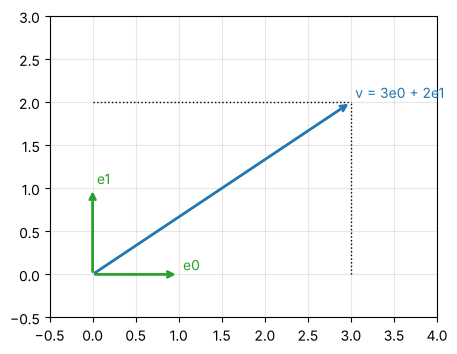

In [2]:
e0, e1 = np.array([1, 0]), np.array([0, 1])
v = 3 * e0 + 2 * e1
print("v =", v)

fig, ax = plt.subplots()
for vec, lab, c in [(e0, "e0", "C2"), (e1, "e1", "C2"), (v, "v = 3e0 + 2e1", "C0")]:
    ax.annotate("", xy=vec, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=c, lw=2))
    ax.text(vec[0] + 0.05, vec[1] + 0.05, lab, color=c)
ax.plot([3, 3], [0, 2], "k:", lw=1); ax.plot([0, 3], [2, 2], "k:", lw=1)
ax.set_xlim(-0.5, 4); ax.set_ylim(-0.5, 3); ax.set_aspect("equal")
plt.show()

## 2. The inner product (dot product)
For real vectors, ⟨u, v⟩ = u₀v₀ + u₁v₁ + …  Geometrically it's |u||v|cos(angle): it measures how much u points along v.
Zero means the vectors are **orthogonal** (at right angles).

u . v = 2.0


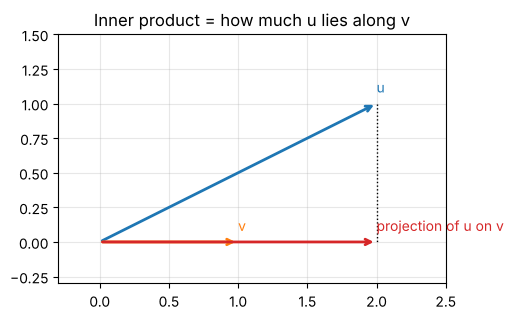

In [3]:
u = np.array([2.0, 1.0]); v = np.array([1.0, 0.0])
print("u . v =", u @ v)
proj = (u @ v) / (v @ v) * v
fig, ax = plt.subplots()
for vec, lab, c in [(u, "u", "C0"), (v, "v", "C1"), (proj, "projection of u on v", "C3")]:
    ax.annotate("", xy=vec, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=c, lw=2))
    ax.text(vec[0], vec[1] + 0.08, lab, color=c)
ax.plot([u[0], proj[0]], [u[1], proj[1]], "k:", lw=1)
ax.set_xlim(-0.3, 2.5); ax.set_ylim(-0.3, 1.5); ax.set_aspect("equal")
ax.set_title("Inner product = how much u lies along v")
plt.show()

## 3. The complex inner product: conjugate the first vector
For complex vectors we use ⟨u, v⟩ = Σ conj(uₖ)·vₖ. Without the conjugate, a vector's "length squared" could come out negative or complex.

NumPy's `np.vdot(u, v)` does the conjugation for you. `u @ v` does **not**. This is the most common bug in quantum code.

In [4]:
u = np.array([1, 1j])
print("u @ u (WRONG, no conjugate):", u @ u)
print("np.vdot(u, u) (correct):    ", np.vdot(u, u))

u @ u (WRONG, no conjugate): 0j
np.vdot(u, u) (correct):     (2+0j)


## 4. Norm and normalisation
The **norm** (length) is ‖v‖ = √⟨v, v⟩. To **normalise**, divide by the norm, giving a vector of length 1.

Quantum states must have norm 1 because the squared amplitudes are probabilities and probabilities add to 1.

In [5]:
v = np.array([3, 4], dtype=complex)
n = np.linalg.norm(v)
v_hat = v / n
print("norm:", n, "  normalised:", v_hat, "  new norm:", np.linalg.norm(v_hat))

norm: 5.0   normalised: [0.6+0.j 0.8+0.j]   new norm: 1.0


## Exercises
**E1.** Normalise v = (1, i, 1).

**E2.** Compute the inner product of your normalised v with (1, 0, 0).

**E3.** Are (1, i)/√2 and (1, −i)/√2 orthogonal? Work it out with the conjugate.

In [6]:
# Your turn
v = np.array([1, 1j, 1])

<details>
<summary><b>Show worked solution</b></summary>

**E1.** ⟨v, v⟩ = |1|² + |i|² + |1|² = 1 + 1 + 1 = 3, so ‖v‖ = √3 and v̂ = (1, i, 1)/√3.

**E2.** ⟨(1, 0, 0), v̂⟩ = conj(1)·(1/√3) = 1/√3 ≈ 0.577. Either order gives the same real number here.

**E3.** ⟨a, b⟩ = (1/2)[conj(1)·1 + conj(i)·(−i)] = (1/2)[1 + (−i)(−i)] = (1/2)[1 + i²] = (1/2)(1 − 1) = 0. Yes, orthogonal.
Without conjugating you'd get (1/2)(1 + 1) = 1, which is the wrong answer.

</details>

In [7]:
v = np.array([1, 1j, 1]); v_hat = v / np.linalg.norm(v)
assert np.isclose(np.linalg.norm(v), np.sqrt(3))
assert np.isclose(np.vdot(np.array([1, 0, 0]), v_hat), 1 / np.sqrt(3))
a, b = np.array([1, 1j]) / np.sqrt(2), np.array([1, -1j]) / np.sqrt(2)
assert np.isclose(np.vdot(a, b), 0)
print("All Day 2 checks passed.")

All Day 2 checks passed.


---
### Recap checklist
Tick these off in your head before moving on. If any feel shaky, re-run the relevant section with your own numbers.

**Next:** Day 3: Linear algebra 2, matrices

*Part of the IIT Delhi CEP Applied Quantum Computing & AI prep plan: [prep-plan.md](../plan/prep-plan.md)*